In [1]:
import time
import copy
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage
import pandas as pd
import torch
from matplotlib.lines import Line2D
from genkit.metrics import mse, msle_90, msle_99
from genkit._sampling import sample_exponential, sample_gaussian, sample_scaled_isotropic_alpha_stable, sample_student_t
from genkit.datasets import fetch_synthetic_data
from genkit.diffusion import DDPMEps
from genkit.flow import GaussianFlowLinear
from genkit.model import LightNet
from genkit.training import train
from genkit.visitor import CoreMetricsVisitor
from genkit.plotting import PRETTY_RCPARAMS


plt.rcParams.update(PRETTY_RCPARAMS)


In [2]:
class StudentSourceMixin:
    def __init__(self, *args, source_nu: float = 3.0, **kwargs):
        super().__init__(*args, **kwargs)
        self._source_nu = float(source_nu)

    def _sample_source_default(self, n_samples: int) -> torch.Tensor:
        return sample_student_t(
            n_samples=n_samples,
            dim=self._dim,
            nu=self._source_nu,
            device=self._device,
            dtype=self._fdtype,
        )


class ExponentialSourceMixin:
    def __init__(self, *args, source_rate: float = 1.0, **kwargs):
        super().__init__(*args, **kwargs)
        self._source_rate = float(source_rate)

    def _sample_source_default(self, n_samples: int) -> torch.Tensor:
        return sample_exponential(
            n_samples=n_samples,
            dim=self._dim,
            rate=self._source_rate,
            device=self._device,
            dtype=self._fdtype,
        )


class AlphaStableSourceMixin:
    def __init__(self, *args, source_alpha: float = 1.5, **kwargs):
        super().__init__(*args, **kwargs)
        self._source_alpha = float(source_alpha)

    def _sample_source_default(self, n_samples: int) -> torch.Tensor:
        return sample_scaled_isotropic_alpha_stable(
            n_samples=n_samples,
            dim=self._dim,
            alpha=self._source_alpha,
            device=self._device,
            dtype=self._fdtype,
        )


class StudentSourceDDPMEps(StudentSourceMixin, DDPMEps):
    pass


class ExponentialSourceDDPMEps(ExponentialSourceMixin, DDPMEps):
    pass


class AlphaStableSourceDDPMEps(AlphaStableSourceMixin, DDPMEps):
    pass


class StudentSourceGaussianFlowLinear(StudentSourceMixin, GaussianFlowLinear):
    pass


class ExponentialSourceGaussianFlowLinear(ExponentialSourceMixin, GaussianFlowLinear):
    pass


class AlphaStableSourceGaussianFlowLinear(AlphaStableSourceMixin, GaussianFlowLinear):
    pass


class MeanMSELossMixin:
    def _loss_fn(self, pred: torch.Tensor, target: torch.Tensor, t: int):
        return (pred - target).square()

    def _reduce(self, loss_values: torch.Tensor) -> torch.Tensor:
        return loss_values.mean()


class MedianMSELossMixin:
    def _loss_fn(self, pred: torch.Tensor, target: torch.Tensor, t: int):
        return (pred - target).square().mean(dim=-1)

    def _reduce(self, loss_values: torch.Tensor) -> torch.Tensor:
        return loss_values.median()


class MeanHuberLossMixin:
    def _loss_fn(self, pred: torch.Tensor, target: torch.Tensor, t: int):
        return torch.nn.functional.huber_loss(pred, target, reduction="none", delta=1.0)

    def _reduce(self, loss_values: torch.Tensor) -> torch.Tensor:
        return loss_values.mean()


class MedianHuberLossMixin:
    def _loss_fn(self, pred: torch.Tensor, target: torch.Tensor, t: int):
        return torch.nn.functional.huber_loss(pred, target, reduction="none", delta=1.0).mean(dim=-1)

    def _reduce(self, loss_values: torch.Tensor) -> torch.Tensor:
        return loss_values.median()


def build_model_specs(nu, rate, alpha):
    family_sources = {
        "DDPMEps": {
            "Gaussian": DDPMEps,
            "Student": StudentSourceDDPMEps,
            "Exponential": ExponentialSourceDDPMEps,
            "AlphaStable": AlphaStableSourceDDPMEps,
        },
        "GaussianFlowLinear": {
            "Gaussian": GaussianFlowLinear,
            "Student": StudentSourceGaussianFlowLinear,
            "Exponential": ExponentialSourceGaussianFlowLinear,
            "AlphaStable": AlphaStableSourceGaussianFlowLinear,
        },
    }
    loss_mixins = {
        "MeanMSE": MeanMSELossMixin,
        "MedianMSE": MedianMSELossMixin,
        "MeanHuber": MeanHuberLossMixin,
        "MedianHuber": MedianHuberLossMixin,
    }
    source_kwargs = {
        "Gaussian": {},
        "Student": {"source_nu": nu},
        "Exponential": {"source_rate": rate},
        "AlphaStable": {"source_alpha": alpha},
    }
    specs = []
    for family, sources in family_sources.items():
        for source_distri, source_cls in sources.items():
            for loss, loss_mixin in loss_mixins.items():
                name = f"{source_distri}{loss}{family}"
                cls = type(name, (loss_mixin, source_cls), {})
                specs.append(
                    {
                        "name": name,
                        "cls": cls,
                        "family": family,
                        "source_distri": source_distri,
                        "loss": loss,
                        "extra_kwargs": dict(source_kwargs[source_distri]),
                    }
                )
    return specs


In [ ]:
dim = 2
rate = 1.0
nu = 3.0
alpha = 1.3
n_samples = 2**12

n_steps = 2**7
batch_size = 2**8
n_epochs = 2**11
lr = 1e-3
width = 2**6
n_blocks = 2**2
n_trials = 3
num_workers = 0
cache_version = 2

device = "cuda" if torch.cuda.is_available() else "cpu"
fdtype = torch.float32
idtype = torch.int32

cache_dir = Path(".cache")
cache_dir.mkdir(exist_ok=True)
cache_path = cache_dir / "03_heavytail_loss_raw_results.pt"


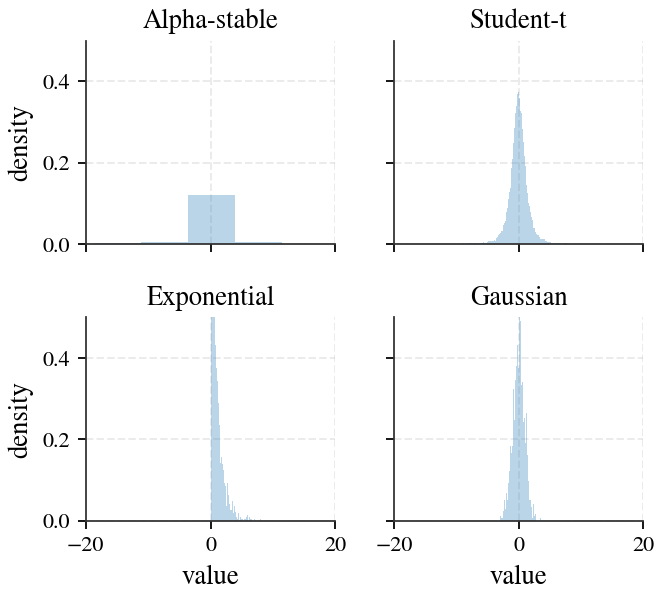

In [4]:
preview_n = 100_000

preview_samples = {
    "Alpha-stable": sample_scaled_isotropic_alpha_stable(n_samples=preview_n, dim=1, alpha=alpha, device='cpu', dtype=torch.float32).squeeze(-1).cpu().numpy(),
    "Student-t": sample_student_t(n_samples=preview_n, dim=1, nu=nu, device='cpu', dtype=torch.float32).squeeze(-1).cpu().numpy(),
    "Exponential": sample_exponential(n_samples=preview_n, dim=1, rate=rate, device='cpu', dtype=torch.float32).squeeze(-1).cpu().numpy(),
    "Gaussian": sample_gaussian(n_samples=preview_n, dim=1, device='cpu', dtype=torch.float32).squeeze(-1).cpu().numpy(),
}

fig, axis = plt.subplots(2, 2, figsize=(4.4, 4.0), squeeze=False, sharex=True, sharey=True)
for ax, (name, values) in zip(axis.flat, preview_samples.items()):
    ax.hist(values, bins=int(preview_n/20), density=True, alpha=0.3, color="tab:blue", label="hist")
    ax.set_xlim(-20, 20)
    ax.set_ylim(0, 0.5)
    ax.set_title(name)

axis[1, 0].set_xlabel("value")
axis[1, 1].set_xlabel("value")
axis[0, 0].set_ylabel("density")
axis[1, 0].set_ylabel("density")

fig.tight_layout()

In [5]:
model_specs = build_model_specs(nu, rate, alpha)
model_class_map = {spec["name"]: spec["cls"] for spec in model_specs}
family_names = list(dict.fromkeys(spec["family"] for spec in model_specs))

x_train, _, x_ref = fetch_synthetic_data(
    "alpha_stable",
    alpha=alpha,
    n_samples=n_samples,
    dim=dim,
    device=device,
    dtype=fdtype,
)

kwargs = dict(
    target_data=x_train,
    batch_size=batch_size,
    n_epochs=n_epochs,
    lr=lr,
    device=device,
    num_workers=num_workers,
)
net_kwargs = dict(width=width, n_blocks=n_blocks)


In [6]:
def build_generator(spec, extra_kwargs, device):
    net = LightNet(dim=dim, **net_kwargs).to(device=device, dtype=fdtype)
    return spec["cls"](
        net=net,
        dim=dim,
        n_steps=n_steps,
        device=device,
        fdtype=fdtype,
        idtype=idtype,
        **extra_kwargs,
    )


def load_raw_results(device, cache_path):
    if not cache_path.exists():
        return None

    print(f"Loading cached raw_results from {cache_path}.")
    cache_payload = torch.load(cache_path, map_location=device)
    if cache_payload.get("cache_version") != cache_version:
        print("Ignoring cache with incompatible version.")
        return None
    if cache_payload.get("n_trials") != n_trials:
        print("Ignoring cache with incompatible number of trials.")
        return None

    models_payload = cache_payload.get("models", {})
    raw_results = {}
    for spec in model_specs:
        model_payload = models_payload.get(spec["name"])
        if model_payload is None:
            print(f"Missing cached model {spec['name']}; retraining.")
            return None

        trials = []
        for trial_payload in model_payload.get("trials", []):
            generator = build_generator(spec, trial_payload["extra_kwargs"], device)
            generator._net.load_state_dict(trial_payload["net_state_dict"])
            trials.append(
                {
                    "generator": generator,
                    "diagnostics": trial_payload["diagnostics"],
                    "extra_kwargs": dict(trial_payload["extra_kwargs"]),
                }
            )

        if len(trials) != n_trials:
            print(f"Incomplete cache for {spec['name']}; retraining.")
            return None

        raw_results[spec["name"]] = {
            "meta": {k: spec[k] for k in ("name", "family", "source_distri", "loss")},
            "trials": trials,
        }

    return raw_results


In [7]:
raw_results = load_raw_results(device, cache_path)
if raw_results is None:
    raw_results = {}
    total_runs = len(model_specs) * n_trials
    run_idx = 0

    for spec in model_specs:
        trials = []
        for trial_idx in range(n_trials):
            run_idx += 1
            t0 = time.time()
            extra_kwargs = dict(spec["extra_kwargs"])
            generator = build_generator(spec, extra_kwargs, device)
            kwargs["generative_model"] = generator
            kwargs["visitors"] = [CoreMetricsVisitor()]

            print(
                f"[{run_idx:02d} / {total_runs:02d}] "
                f"{spec['name']} trial {trial_idx + 1}/{n_trials}: Training...",
                end="",
            )
            generator, diagnostics = train(**kwargs)
            print(f"Done (in {time.time() - t0:.1f} s).")

            trials.append(
                {
                    "generator": generator,
                    "diagnostics": diagnostics,
                    "extra_kwargs": extra_kwargs,
                }
            )

        raw_results[spec["name"]] = {
            "meta": {k: spec[k] for k in ("name", "family", "source_distri", "loss")},
            "trials": trials,
        }


[01 / 96] GaussianMeanMSEDDPMEps trial 1/3: Training...Done (in 18.5 s).
[02 / 96] GaussianMeanMSEDDPMEps trial 2/3: Training...Done (in 13.9 s).
[03 / 96] GaussianMeanMSEDDPMEps trial 3/3: Training...Done (in 17.3 s).
[04 / 96] GaussianMedianMSEDDPMEps trial 1/3: Training...Done (in 14.4 s).
[05 / 96] GaussianMedianMSEDDPMEps trial 2/3: Training...Done (in 14.4 s).
[06 / 96] GaussianMedianMSEDDPMEps trial 3/3: Training...Done (in 18.3 s).
[07 / 96] GaussianMeanHuberDDPMEps trial 1/3: Training...Done (in 14.7 s).
[08 / 96] GaussianMeanHuberDDPMEps trial 2/3: Training...Done (in 18.1 s).
[09 / 96] GaussianMeanHuberDDPMEps trial 3/3: Training...Done (in 14.0 s).
[10 / 96] GaussianMedianHuberDDPMEps trial 1/3: Training...Done (in 17.8 s).
[11 / 96] GaussianMedianHuberDDPMEps trial 2/3: Training...Done (in 14.5 s).
[12 / 96] GaussianMedianHuberDDPMEps trial 3/3: Training...Done (in 18.4 s).
[13 / 96] StudentMeanMSEDDPMEps trial 1/3: Training...Done (in 15.3 s).
[14 / 96] StudentMeanMSEDDPM

In [8]:
cache_payload = {"cache_version": cache_version, "n_trials": n_trials, "models": {}}
for spec in model_specs:
    model_payload = {
        "meta": raw_results[spec["name"]]["meta"],
        "trials": [],
    }
    for trial in raw_results[spec["name"]]["trials"]:
        model_payload["trials"].append(
            {
                "extra_kwargs": dict(trial["extra_kwargs"]),
                "net_state_dict": trial["generator"]._net.state_dict(),
                "diagnostics": trial["diagnostics"],
            }
        )
    cache_payload["models"][spec["name"]] = model_payload

torch.save(cache_payload, cache_path)
print(f"Saved raw_results cache to {cache_path}.")


Saved raw_results cache to .cache/03_heavytail_loss_raw_results_v2.pt.


In [63]:
n_points = 15
pts_every = max(1, int(n_epochs / n_points))

source_colors = {
    "Gaussian": "tab:blue",
    "Student": "tab:orange",
    "Exponential": "tab:green",
    "AlphaStable": "tab:red",
}


def curve_style(spec):
    color = source_colors[spec["source_distri"]]
    linestyle = "solid" if spec["loss"].startswith("Mean") else "dashed"
    marker = "o" if spec["loss"].endswith("MSE") else "s"
    return color, linestyle, marker


def averaged_grad_curve(result):
    curves = []
    for trial in result["trials"]:
        grad_var = np.asarray(
            trial["diagnostics"]["visitors"]["core"]["grad_variance_epoch"],
            dtype=float,
        )
        curves.append(grad_var[::pts_every])
    return np.mean(np.stack(curves, axis=0), axis=0)


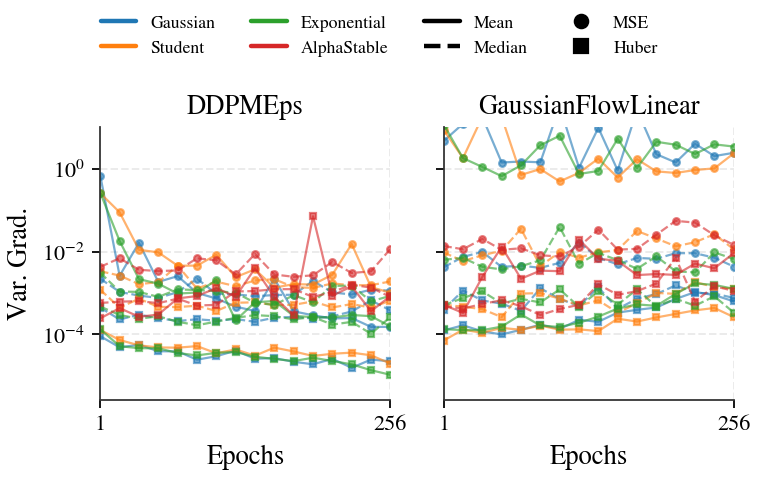

In [64]:
results = copy.deepcopy(raw_results)

fig, axes = plt.subplots(1, len(family_names), figsize=(5.0, 3.0), squeeze=False, sharey=True)
family_to_ax = {family: axes[0, idx] for idx, family in enumerate(family_names)}

for spec in model_specs:
    ax = family_to_ax[spec["family"]]
    avg_curve = averaged_grad_curve(results[spec["name"]])
    x = np.linspace(1, n_epochs, len(avg_curve), dtype=int)
    color, linestyle, marker = curve_style(spec)
    ax.plot(
        x,
        avg_curve,
        color=color,
        ls=linestyle,
        marker=marker,
        lw=1.0,
        ms=3,
        alpha=0.6,
    )

for family, ax in family_to_ax.items():
    ax.set_title(family)
    ax.set_yscale("log")
    ax.set_xlim(1, n_epochs)
    ax.set_xticks([1, n_epochs], ["1", f"{n_epochs}"])
    ax.set_xlabel("Epochs")
    ax.set_ylim(top=10.0)

axes[0, 0].set_ylabel("Var. Grad.")

legend_handles = [
    *[
        Line2D([0], [0], color=color, lw=2, label=source_name)
        for source_name, color in source_colors.items()
    ],
    Line2D([0], [0], color="black", lw=2, ls="solid", label="Mean"),
    Line2D([0], [0], color="black", lw=2, ls="dashed", label="Median"),
    Line2D([0], [0], color="black", lw=0, marker="o", markersize=6, label="MSE"),
    Line2D([0], [0], color="black", lw=0, marker="s", markersize=6, label="Huber"),
]
fig.legend(
    legend_handles,
    [handle.get_label() for handle in legend_handles],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=4,
    frameon=False,
    fontsize=8,
)

fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.9))


In [52]:
results = copy.deepcopy(raw_results)

rows = []
for spec in model_specs:
    result = results[spec["name"]]
    trial_metrics = []
    for trial_idx, trial in enumerate(result["trials"], start=1):
        with torch.no_grad():
            x_gen = trial["generator"].sample(len(x_ref))

        trial_metrics.append(
            {
                "trial": trial_idx,
                "test-MSE": float(mse(x_gen, x_ref)),
                "test-MSLE90": float(msle_90(x_gen, x_ref)),
                "test-MSLE99": float(msle_99(x_gen, x_ref)),
            }
        )

    row = {
        "family": spec["family"],
        "source_distri": spec["source_distri"],
        "loss": spec["loss"],
        "n_trials": len(trial_metrics),
    }
    for metric_name in ("test-MSE", "test-MSLE90", "test-MSLE99"):
        values = [trial_metric[metric_name] for trial_metric in trial_metrics]
        row[metric_name] = float(np.mean(values))
        row[f"{metric_name}-std"] = float(np.std(values))
    rows.append(row)

df = pd.DataFrame(rows).sort_values(["family", "source_distri", "loss"]).reset_index(drop=True)


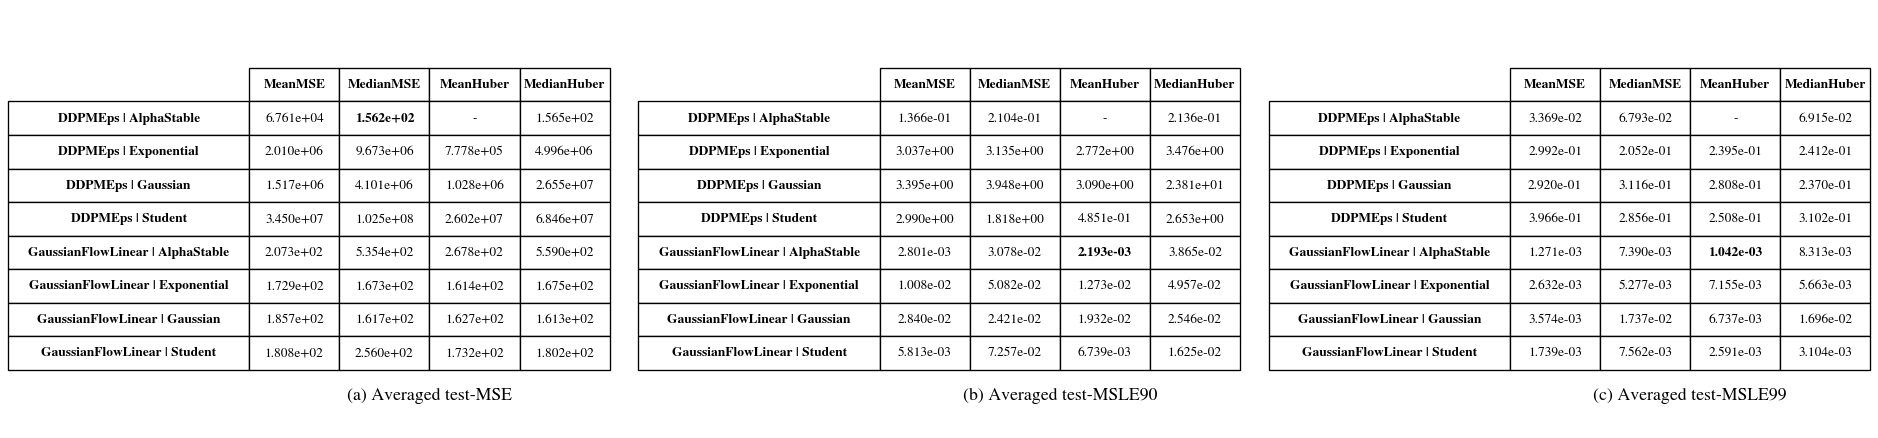

In [53]:
tables = {}
for caption, metric_name in {
    "(a) Averaged test-MSE": "test-MSE",
    "(b) Averaged test-MSLE90": "test-MSLE90",
    "(c) Averaged test-MSLE99": "test-MSLE99",
}.items():
    table_df = df.pivot_table(
        index=["family", "source_distri"],
        columns="loss",
        values=metric_name,
        aggfunc="mean",
    )
    table_df = table_df.reindex(columns=["MeanMSE", "MedianMSE", "MeanHuber", "MedianHuber"])
    table_df.index = [f"{family} | {source}" for family, source in table_df.index]
    tables[caption] = table_df

fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.0))

for ax, (caption, table_df) in zip(axes, tables.items()):
    ax.axis("off")
    formatted = table_df.map(lambda x: "-" if pd.isna(x) else f"{x:.3e}")
    min_mask = table_df.eq(table_df.min().min())

    table = ax.table(
        cellText=formatted.values,
        rowLabels=formatted.index,
        colLabels=formatted.columns,
        cellLoc="center",
        rowLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(6)
    table.scale(1.0, 1.1)

    for (row, col), cell in table.get_celld().items():
        cell.set_linewidth(0.6)
        if row == 0 or col == -1:
            cell.set_text_props(weight="bold")
        elif row > 0 and col >= 0 and min_mask.iloc[row - 1, col]:
            cell.set_text_props(weight="bold")

    ax.text(0.5, 0.1, caption, transform=ax.transAxes, ha="center", va="top", fontsize=8)

fig.tight_layout()
